In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [19]:
def clamp01(x):
    return float(np.clip(x, 0.0, 1.0))

def classify_hue_opencv(h_med):
    """
    h_med: hue in [0,179] (OpenCV)
    returns label
    """
    if h_med is None:
        return "unknown"

    # red wrap-around
    if (0 <= h_med <= 10) or (170 <= h_med <= 179):
        return "red"
    if 11 <= h_med <= 25:
        return "orange"
    if 26 <= h_med <= 35:
        return "yellow"
    if 40 <= h_med <= 85:
        return "green"
    if 86 <= h_med <= 100:
        return "cyan"
    if 101 <= h_med <= 130:
        return "blue"
    if 131 <= h_med <= 169:
        return "violet"
    return "unknown"

def detect_led_color_hsv(img_bgr,
                         s_thresh=80, v_thresh=200,
                         min_area=30, max_area=8000,
                         v_not_saturated=250):
    """
    Returns: dict with label, confidence, bbox, reason, stats
    bbox: (x,y,w,h) or None
    """
    if img_bgr is None or img_bgr.size == 0:
        return {"label": "unknown", "confidence": 0.0, "bbox": None, "reason": "empty_image"}

    # 1) preprocess
    blur = cv2.GaussianBlur(img_bgr, (5, 5), 0)

    # 2) HSV + threshold
    hsv = cv2.cvtColor(blur, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)

    mask = ((S >= s_thresh) & (V >= v_thresh)).astype(np.uint8) * 255

    # 3) morphology cleanup
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)

    # 4) pick best contour
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return {"label": "off", "confidence": 0.0, "bbox": None, "reason": "no_candidate_blob"}

    best = None
    best_score = -1

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue

        x, y, w, h = cv2.boundingRect(cnt)

        # mean V inside contour (quick approx: use bounding box masked by contour)
        roi_V = V[y:y+h, x:x+w]
        roi_mask = np.zeros((h, w), dtype=np.uint8)
        cv2.drawContours(roi_mask, [cnt - [x, y]], -1, 255, -1)

        v_vals = roi_V[roi_mask == 255]
        if v_vals.size == 0:
            continue
        v_mean = float(np.mean(v_vals))

        # score: brighter and reasonable size
        score = v_mean + 0.01 * area
        if score > best_score:
            best_score = score
            best = (cnt, x, y, w, h, area, v_mean)

    if best is None:
        return {"label": "unknown", "confidence": 0.0, "bbox": None, "reason": "all_blobs_filtered"}

    cnt, x, y, w, h, area, v_mean = best
    bbox = (int(x), int(y), int(w), int(h))

    # 5) compute robust hue on valid pixels (avoid saturated V)
    roi_H = H[y:y+h, x:x+w]
    roi_S = S[y:y+h, x:x+w]
    roi_V = V[y:y+h, x:x+w]

    roi_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.drawContours(roi_mask, [cnt - [x, y]], -1, 255, -1)

    valid = (roi_mask == 255) & (roi_S >= s_thresh) & (roi_V >= v_thresh) & (roi_V < v_not_saturated)

    h_vals = roi_H[valid]
    s_vals = roi_S[valid]
    v_vals = roi_V[valid]

    # fallback: if everything is saturated, allow saturated pixels (less reliable)
    if h_vals.size < 20:
        valid2 = (roi_mask == 255) & (roi_S >= s_thresh) & (roi_V >= v_thresh)
        h_vals = roi_H[valid2]
        s_vals = roi_S[valid2]
        v_vals = roi_V[valid2]

    if h_vals.size < 10:
        # likely OFF or too small / too few valid pixels
        # check if blob is bright at least; otherwise it's off
        label = "off" if v_mean < v_thresh else "unknown"
        return {"label": label, "confidence": 0.1 if label=="unknown" else 0.0,
                "bbox": bbox, "reason": "too_few_valid_pixels",
                "stats": {"area": area, "v_mean": v_mean}}

    h_med = float(np.median(h_vals))
    s_med = float(np.median(s_vals))
    v_med = float(np.median(v_vals))

    # Robust dispersion (MAD) for purity
    mad = float(np.median(np.abs(h_vals - h_med)))  # in hue units [0..179]

    label = classify_hue_opencv(h_med)

    # 6) confidence
    # purity: mad small => high confidence. 0..~20 typical
    purity = clamp01(1.0 - (mad / 15.0))            # tune denominator
    brightness = clamp01((v_med - v_thresh) / (255 - v_thresh))
    coverage = clamp01(h_vals.size / 500.0)         # assumes blob has hundreds of pixels when good

    confidence = clamp01(0.5*purity + 0.3*brightness + 0.2*coverage)

    # If label unknown, down-weight
    if label == "unknown":
        confidence *= 0.4

    return {
        "label": label,
        "confidence": float(confidence),
        "bbox": bbox,
        "reason": "ok",
        "stats": {
            "h_med": h_med, "s_med": s_med, "v_med": v_med
           # "mad_h": mad, "area": float(area),
            #"n_valid": int(h_vals.size)
        }
    }

In [ ]:
def visualize_result(img_bgr, res, title="LED detection"):
    vis = img_bgr.copy()

    label = res.get("label", "unknown")
    conf = res.get("confidence", 0.0)
    bbox = res.get("bbox", None)

    if bbox is not None:
        x, y, w, h = bbox
        # Rectangle
        cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Text background (better readability)
        text = f"{label} {conf:.2f}"
        (tw, th), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        tx, ty = x, max(0, y - 10)

        # Put a filled rectangle behind the text
        cv2.rectangle(vis, (tx, ty - th - baseline), (tx + tw, ty + baseline), (0, 255, 0), -1)
        cv2.putText(vis, text, (tx, ty),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2, cv2.LINE_AA)
    else:
        # If no bbox, still show label/conf
        text = f"{label} {conf:.2f}"
        cv2.putText(vis, text, (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2, cv2.LINE_AA)

    # Show with matplotlib
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 7))
    plt.imshow(vis_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [29]:
img_path = 'color_detection/red.jpg'
img = cv2.imread(img_path)
res = detect_led_color_hsv(img)
print ("detected_color:",res["label"])
print( "confidence:", res["confidence"])
print("HSV values:", res["stats"])

detected_color: red
confidence: 0.8345454545454545
HSV values: {'h_med': 176.0, 's_med': 157.0, 'v_med': 243.0}


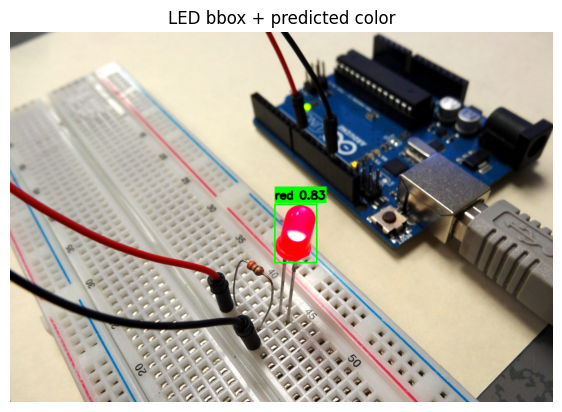

In [30]:
visualize_result(img, res, title="LED bbox + predicted color")